In [1]:
import copy
import datetime
import itertools
import json
import os
import pathlib
import re

import IPython.display
import matplotlib
import matplotlib.markers
import matplotlib.pyplot
import matplotlib.style
import matplotlib.ticker
import matplotlib.transforms
import numpy
import polars
import tqdm.notebook

from utils import taxonomy
from utils import list_code

JSON2CBOR_EVAL_DIR = pathlib.Path.cwd() / "03_json2cbor_eval"
os.environ["JSON2CBOR_EVAL_DIR"] = str(JSON2CBOR_EVAL_DIR)

OUTPUT_PATH = pathlib.Path(JSON2CBOR_EVAL_DIR) / "plots"
if not OUTPUT_PATH.exists():
    OUTPUT_PATH.mkdir()


def cdf(values, bin_size=0.01):
    bins = numpy.arange(values.min(), values.max(), bin_size)
    hist, x = numpy.histogram(values, bins=bins, density=1)
    if len(x) < 2:
        return numpy.array([]), numpy.array([])
    dx = x[1] - x[0]
    return x[1:], (numpy.cumsum(hist) * dx)


def plot_cdf(axs, df, label, style={}, bin_size=0.01):
    x, y = cdf(df, bin_size=bin_size)
    for ax in axs:
        ax.plot(x, y, label=label, **style)

# Evaluating the Use of CBOR for Object Encoding
## Method

We summarize our method in the figure below (Figure 3 in the paper).
We first scrape GitHub for JSON files (left-hand side) which we store in the file system and then use those JSONs to convert them to CBOR on a Raspberry Pi (right-hand side).
During conversion the taxonomy is determined according to the method proposed by Viotti and Kinderkhedia in their work “[A Benchmark of JSON-compatible Binary Serialization Specifications Technical Report](https://arxiv.org/abs/2201.03051)”.

In [2]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}
\usepackage{fontawesome5}
\usepackage[T1]{fontenc}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}
\usepackage{tikz}

\usetikzlibrary{
  calc,
  colorbrewer,
  fadings,
  fit,
  positioning
}
\pgfdeclarelayer{bg}
\pgfdeclarelayer{fg}
\pgfsetlayers{bg,main,fg}
\graphicspath{{03_json2cbor_eval/figs/}}
"""

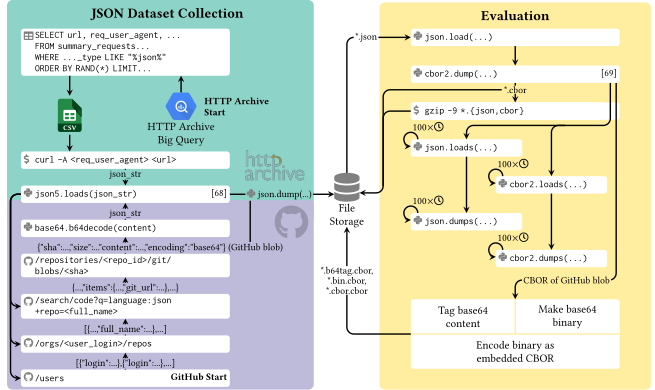

In [3]:
%%tikz -p "$preamble" -S "03_json2cbor_eval/figs/json-collect"
\adjustbox{scale=1.4}{\input{03_json2cbor_eval/figs/json-collect.tex}}

## Dataset Collection

Due to the rate-limiting imposed by GitHub and our method of doing the conversion to CBOR on a Raspberry Pi to achieve reproducible runtimes, the dataset collection can take several weeks.
All information and ways to reproduce this, can be found in [this notebook](03_json2cbor_eval/01_dataset_collection.ipynb).

We also provided our JSON and CBOR files in `03_json2cbor_eval.tar.xz` on [Zenodo](https://tbd):

In [4]:
%%bash
wget -O 03_json2cbor_eval.tar.xz https://tbd
md5sum --status -c "${JSON2CBOR_EVAL_DIR}"/03_json2cbor_eval.tar.xz.md5sum && \
    XZ_OPT=-T0 tar -C "${JSON2CBOR_EVAL_DIR}/.." -xJf 03_json2cbor_eval.tar.xz
tar -C "${JSON2CBOR_EVAL_DIR}" -I pigz -xf "${JSON2CBOR_EVAL_DIR}/jsons.tar.gz"

The CBOR files are in `03_json2cbor_eval/cbors.tar.gz` in the same `03_json2cbor_eval.tbd`.
However, **they are not needed for the commands below**.
If you want to unpack them anyway, use the following command:

In [5]:
%%bash
tar -C "${JSON2CBOR_EVAL_DIR}" -I pigz -xf "${JSON2CBOR_EVAL_DIR}/cbors.tar.gz"

`json2cbor_rpi3.csv.gz` and `json2cbor_epyc7702.csv.gz` which are used in the commands below are also provided in `03_json2cbor_eval.tar.xz`.

## Initial Dataset Exploration

This provides a broad numeric overview over the dataset of JSONs and CBORs.

In [6]:
lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "json2cbor_epyc7702.csv.gz",
    separator=";",
).with_columns(
    dataset=polars.col("json_filename").str.split("/").list.first()
).group_by("dataset").agg(
    total=polars.col("dataset").count(),
    # polars filter returns a list of true and false, summing that up results in the number of trues
    github_api=((polars.col("dataset") == "github") & (polars.col("github_type") != "stored_json")).sum(),
    stored_json=(polars.col("github_type") == "stored_json").sum(),
    blobs=((polars.col("dataset") == "github") & (polars.col("github_type") == "github_api_blob")).sum(),
    unparsable_blobs=(
        ((polars.col("dataset") == "github") & (polars.col("github_type") == "github_api_blob")).sum()
        - ((polars.col("dataset") == "github") & (polars.col("github_type") == "stored_json")).sum()
    ),
    tier_1=(polars.col("json_size_tier") == 1).sum(),
    tier_2=(polars.col("json_size_tier") == 2).sum(),
    tier_3=(polars.col("json_size_tier") == 3).sum(),
    tier_sum=polars.col("json_size_tier").is_in([1, 2, 3]).sum(),
    textual=(polars.col("json_content_type") == "Textual").sum(),
    numeric=(polars.col("json_content_type") == "Numeric").sum(),
    boolean=(polars.col("json_content_type") == "Boolean").sum(),
    structural=(polars.col("json_content_type") == "Structural").sum(),
    content_type_sum=polars.col("json_content_type").is_in(["Textual", "Numeric", "Boolean", "Structural"]).sum(),
    redundant=(polars.col("json_redundancy") == "Redundant").sum(),
    non_redundant=(polars.col("json_redundancy") == "Non-redundant").sum(),
    redundancy_sum=polars.col("json_redundancy").is_in(["Redundant", "Non-redundant"]).sum(),
    flat=(polars.col("json_structure") == "Flat").sum(),
    nested=(polars.col("json_structure") == "Nested").sum(),
    structure_sum=polars.col("json_structure").is_in(["Flat", "Nested"]).sum(),
    textual_non_redundant_flat=(
        (polars.col("json_content_type") == "Textual")
        & (polars.col("json_redundancy") == "Non-redundant")
        & (polars.col("json_structure") == "Flat")
    ).sum(),
    stored_tier_1=((polars.col("github_type") == "stored_json") & (polars.col("json_size_tier") == 1)).sum(),
    stored_tier_2=((polars.col("github_type") == "stored_json") & (polars.col("json_size_tier") == 2)).sum(),
    stored_tier_3=((polars.col("github_type") == "stored_json") & (polars.col("json_size_tier") == 3)).sum(),
    stored_tier_sum=((polars.col("github_type") == "stored_json") & polars.col("json_size_tier").is_in([1, 2, 3])).sum(),
    stored_textual=((polars.col("github_type") == "stored_json") & (polars.col("json_content_type") == "Textual")).sum(),
    stored_numeric=((polars.col("github_type") == "stored_json") & (polars.col("json_content_type") == "Numeric")).sum(),
    stored_boolean=((polars.col("github_type") == "stored_json") & (polars.col("json_content_type") == "Boolean")).sum(),
    stored_structural=((polars.col("github_type") == "stored_json") & (polars.col("json_content_type") == "Structural")).sum(),
    stored_content_type_sum=((polars.col("github_type") == "stored_json") & polars.col("json_content_type").is_in(["Textual", "Numeric", "Boolean", "Structural"])).sum(),
    stored_redundant=((polars.col("github_type") == "stored_json") & (polars.col("json_redundancy") == "Redundant")).sum(),
    stored_non_redundant=((polars.col("github_type") == "stored_json") & (polars.col("json_redundancy") == "Non-redundant")).sum(),
    stored_redundancy_sum=((polars.col("github_type") == "stored_json") & polars.col("json_redundancy").is_in(["Redundant", "Non-redundant"])).sum(),
    stored_flat=((polars.col("github_type") == "stored_json") & (polars.col("json_structure") == "Flat")).sum(),
    stored_nested=((polars.col("github_type") == "stored_json") & (polars.col("json_structure") == "Nested")).sum(),
    stored_structure_sum=((polars.col("github_type") == "stored_json") & polars.col("json_structure").is_in(["Flat", "Nested"])).sum(),
    blobs_tier_1=((polars.col("github_type") == "github_api_blob") & (polars.col("json_size_tier") == 1)).sum(),
    blobs_tier_2=((polars.col("github_type") == "github_api_blob") & (polars.col("json_size_tier") == 2)).sum(),
    blobs_tier_3=((polars.col("github_type") == "github_api_blob") & (polars.col("json_size_tier") == 3)).sum(),
    blobs_tier_sum=((polars.col("github_type") == "github_api_blob") & polars.col("json_size_tier").is_in([1, 2, 3])).sum(),
    blobs_textual=((polars.col("github_type") == "github_api_blob") & (polars.col("json_content_type") == "Textual")).sum(),
    blobs_numeric=((polars.col("github_type") == "github_api_blob") & (polars.col("json_content_type") == "Numeric")).sum(),
    blobs_boolean=((polars.col("github_type") == "github_api_blob") & (polars.col("json_content_type") == "Boolean")).sum(),
    blobs_structural=((polars.col("github_type") == "github_api_blob") & (polars.col("json_content_type") == "Structural")).sum(),
    blobs_content_type_sum=((polars.col("github_type") == "github_api_blob") & polars.col("json_content_type").is_in(["Textual", "Numeric", "Boolean", "Structural"])).sum(),
    blobs_redundant=((polars.col("github_type") == "github_api_blob") & (polars.col("json_redundancy") == "Redundant")).sum(),
    blobs_non_redundant=((polars.col("github_type") == "github_api_blob") & (polars.col("json_redundancy") == "Non-redundant")).sum(),
    blobs_redundancy_sum=((polars.col("github_type") == "github_api_blob") & polars.col("json_redundancy").is_in(["Redundant", "Non-redundant"])).sum(),
    blobs_flat=((polars.col("github_type") == "github_api_blob") & (polars.col("json_structure") == "Flat")).sum(),
    blobs_nested=((polars.col("github_type") == "github_api_blob") & (polars.col("json_structure") == "Nested")).sum(),
    blobs_structure_sum=((polars.col("github_type") == "github_api_blob") & polars.col("json_structure").is_in(["Flat", "Nested"])).sum(),
    start_time=polars.from_epoch(polars.col("json_mtime").min()),
    end_time=polars.from_epoch(polars.col("json_mtime").max()),
).with_columns(
    dataset=polars.when(
        polars.col("dataset") == "harch"
    ).then(polars.lit("HTTP Archive")).otherwise(
        polars.when(
            polars.col("dataset") == "github"
        ).then(polars.lit("GitHub")).otherwise(polars.lit("Other"))
    )
).sort("dataset")

# convert to pandas and transpose since polars can not transpose
# to multi-type columns (stats contain ints and datetypes)
df = lf.collect().to_pandas().set_index("dataset").T
df.index.name = "stat"
df

dataset,GitHub,HTTP Archive
stat,,
total,287636,120929
github_api,164365,0
stored_json,123271,120929
blobs,128643,0
unparsable_blobs,5372,0
tier_1,9637,39242
tier_2,99610,41625
tier_3,178389,40058
tier_sum,287636,120925


## JSON Dataset Taxonomy

### Plot Taxonomy

Here, we plot the taxonomy of the scraped JSON files according to Viotti and Kinderkhedia in their work “[A Benchmark of JSON-compatible Binary Serialization Specifications Technical Report](https://arxiv.org/abs/2201.03051)”. This results in Figure 4 of the paper.

#### GitHub

##### [Size Tier](03_json2cbor_eval/plots/json-taxonomy-tier.pdf)

json_size_tier,ratio
str,f64
"""Tier 1""",0.078177
"""Tier 2""",0.459662
"""Tier 3""",0.462161


\begin{tabular}{lr}
\toprule
Tier & Ratio \\
\midrule
1 ($< 100$ bytes) & $7.8\%$ \\
2 ($< 1000$ bytes) & $46.0\%$ \\
3 ($\geq 1000$ bytes) & $46.2\%$ \\
\bottomrule
\end{tabular}



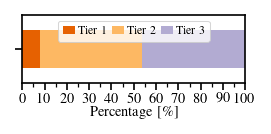

##### [Content Type](03_json2cbor_eval/plots/json-taxonomy-content-type.pdf)

json_content_type,ratio
str,f64
"""Structural""",0.001898
"""Numeric""",0.099123
"""Textual""",0.898979


\begin{tabular}{lr}
\toprule
Content Type & Ratio \\
\midrule
Numeric & $9.9\%$ \\
Structural & $0.2\%$ \\
Textual & $89.9\%$ \\
\bottomrule
\end{tabular}



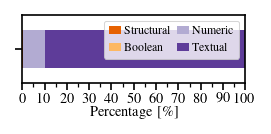

##### [Redundancy](03_json2cbor_eval/plots/json-taxonomy-redundancy.pdf)

json_redundancy,ratio
str,f64
"""Non-redundant""",0.686966
"""Redundant""",0.313034


\begin{tabular}{lr}
\toprule
Redundancy & Ratio \\
\midrule
Non-redundant & $68.7\%$ \\
Redundant & $31.3\%$ \\
\bottomrule
\end{tabular}



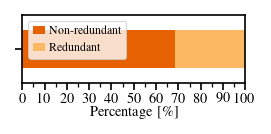

##### [Structure](03_json2cbor_eval/plots/json-taxonomy-structure.pdf)

json_structure,ratio
str,f64
"""Flat""",0.665688
"""Nested""",0.334312


\begin{tabular}{lr}
\toprule
Structure & Ratio \\
\midrule
Flat & $66.6\%$ \\
Nested & $33.4\%$ \\
\bottomrule
\end{tabular}



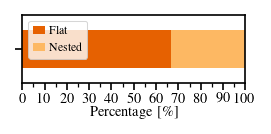

#### HTTP Archive

##### [Size Tier](03_json2cbor_eval/plots/json-taxonomy-tier_harch.pdf)

json_size_tier,ratio
str,f64
"""Tier 1""",0.324515
"""Tier 2""",0.344222
"""Tier 3""",0.331263


\begin{tabular}{lr}
\toprule
Tier & Ratio \\
\midrule
1 ($< 100$ bytes) & $32.5\%$ \\
2 ($< 1000$ bytes) & $34.4\%$ \\
3 ($\geq 1000$ bytes) & $33.1\%$ \\
\bottomrule
\end{tabular}



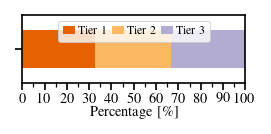

##### [Content Type](03_json2cbor_eval/plots/json-taxonomy-content-type_harch.pdf)

json_content_type,ratio
str,f64
"""Structural""",0.057325
"""Numeric""",0.171131
"""Textual""",0.771544


\begin{tabular}{lr}
\toprule
Content Type & Ratio \\
\midrule
Numeric & $17.1\%$ \\
Structural & $5.7\%$ \\
Textual & $77.2\%$ \\
\bottomrule
\end{tabular}



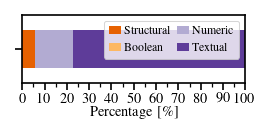

##### [Redundancy](03_json2cbor_eval/plots/json-taxonomy-redundancy_harch.pdf)

json_redundancy,ratio
str,f64
"""Non-redundant""",0.645929
"""Redundant""",0.354071


\begin{tabular}{lr}
\toprule
Redundancy & Ratio \\
\midrule
Non-redundant & $64.6\%$ \\
Redundant & $35.4\%$ \\
\bottomrule
\end{tabular}



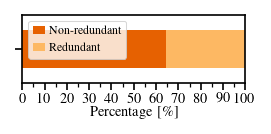

##### [Structure](03_json2cbor_eval/plots/json-taxonomy-structure_harch.pdf)

json_structure,ratio
str,f64
"""Flat""",0.735522
"""Nested""",0.264478


\begin{tabular}{lr}
\toprule
Structure & Ratio \\
\midrule
Flat & $73.6\%$ \\
Nested & $26.4\%$ \\
\bottomrule
\end{tabular}



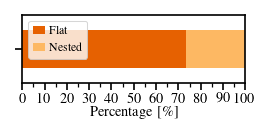

In [7]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] / 2,
)
matplotlib.rcParams["legend.fontsize"] = "xx-small"
matplotlib.rcParams["legend.columnspacing"] = 0.4
matplotlib.rcParams["legend.handletextpad"] = 0.3
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ["#e66101", "#fdb863", "#b2abd2", "#5e3c99"]
)

DATASET_TITLE = {
    "github": "GitHub",
    "harch": "HTTP Archive",
}
DATASET_SUFFIX = {
    "github": "",
    "harch": "_harch",
}
TAXONOMY_TITLE = {
    "json_size_tier": "Size Tier",
    "json_content_type": "Content Type",
    "json_redundancy": "Redundancy",
    "json_structure": "Structure",
}
TAXONOMY_FILENAME = {
    "json_size_tier": "tier",
    "json_content_type": "content-type",
    "json_redundancy": "redundancy",
    "json_structure": "structure",
}
TAXONOMY_TABLE_TITLE = {
    "json_size_tier": "Tier",
    "json_content_type": "Content Type",
    "json_redundancy": "Redundancy",
    "json_structure": "Structure",
}
TAXONOMY_ORDER = {
    "json_content_type": ["Structural", "Boolean", "Numeric", "Textual"]
}
LEGEND_ARGS = {
    "json_size_tier": {"loc": "upper center", "ncol": 3},
    "json_content_type": {"loc": "upper right", "ncol": 2},
    "json_redundancy": {"loc": "upper left"},
    "json_structure": {"loc": "upper left"},
}

lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "json2cbor_epyc7702.csv.gz",
    separator=";",
).with_columns(
    dataset=polars.col("json_filename").str.split("/").list.first()
).filter(polars.col("github_type") == "stored_json")

def table_label(series):
    if "Tier" in series.index:
        series["Tier"] = {
            "Tier 1": "1 ($< 100$ bytes)",
            "Tier 2": "2 ($< 1000$ bytes)",
            "Tier 3": r"3 ($\geq 1000$ bytes)",
        }[series["Tier"]]
    return series

for dataset, in lf.select(["dataset"]).unique().sort("dataset").collect().iter_rows():
    IPython.display.display(IPython.display.Markdown(f"#### {DATASET_TITLE[dataset]}"))
    for tax_cls in ["json_size_tier", "json_content_type", "json_redundancy", "json_structure"]:
        filepath = OUTPUT_PATH / f"json-taxonomy-{TAXONOMY_FILENAME[tax_cls]}{DATASET_SUFFIX[dataset]}.pdf"
        IPython.display.display(
            IPython.display.Markdown(
                f"##### [{TAXONOMY_TITLE[tax_cls]}]({str(filepath.relative_to(pathlib.Path.cwd()))})"
            )
        )
        df = lf.filter(
            (polars.col("dataset") == dataset)
            & polars.col(tax_cls).is_not_null()
        ).group_by(tax_cls).agg(
            count=polars.col(tax_cls).count()
        ).with_columns(
            ratio=polars.col("count") / polars.col("count").sum(),
            sort_idx=polars.when(
                tax_cls in TAXONOMY_ORDER
            ).then(
                polars.col(tax_cls).map_elements(
                    lambda x: TAXONOMY_ORDER[tax_cls].index(x),
                    return_dtype=polars.UInt8,
                )
            ).otherwise(polars.col(tax_cls))
        ).sort("sort_idx").select([tax_cls, "ratio"]).collect()
        
        if tax_cls == "json_size_tier":
            df = df.with_columns(
                polars.format(
                    "Tier {}",
                    polars.col(tax_cls)
                ).alias(tax_cls)
            )
        IPython.display.display(df)
        print(
            df.sort(tax_cls).to_pandas().rename(
                columns={
                    tax_cls: TAXONOMY_TABLE_TITLE[tax_cls],
                    "ratio": "Ratio",
                }
            ).apply(
                table_label,
                axis=1,
            ).to_latex(
                float_format=lambda x: fr"${x * 100:.1f}\%$",
                index=False,
            )
        )
        if tax_cls == "json_content_type" and df.filter(df[tax_cls] == "Boolean").is_empty():
            df = polars.concat(
                [
                    df,
                    polars.DataFrame(
                        [{tax_cls: "Boolean", "ratio": 0.0}]
                    ),
                ]
            ).with_columns(
                sort_idx=polars.col(tax_cls).map_elements(
                    lambda x: TAXONOMY_ORDER[tax_cls].index(x),
                    return_dtype=polars.UInt8,
                )
        ).sort("sort_idx").select([tax_cls, "ratio"])
        df = df.with_columns(
            bottom=polars.col("ratio").cum_sum() - polars.col("ratio")
        ).select([tax_cls, "ratio", "bottom"])
        fig = matplotlib.pyplot.figure(
            figsize=matplotlib.rcParams["figure.figsize"],
            dpi=150,
        )
        ax = matplotlib.pyplot.gca()
        for label, ratio, bottom in df.iter_rows():
            matplotlib.pyplot.barh(
                0, ratio, left=bottom, label=label, height=0.55
            )
        ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1, symbol=""))
        ax.set_xlim((0, 1))
        ax.set_xticks(numpy.arange(0, 1.1, 0.1))
        ax.set_xlabel(r"Percentage [\%]")
        ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
        ax.set_yticks([0])
        ax.set_yticklabels([])
        ax.set_ylim((-0.5, 0.5))
        ax.legend(
            **LEGEND_ARGS[tax_cls],
        )
        matplotlib.pyplot.show()

### Plot Sizes as CDF

In [8]:
lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "json2cbor_epyc7702.csv.gz",
    separator=";",
).with_columns(
    dataset=polars.col("json_filename").str.split("/").list.first()
).filter(
    (polars.col("dataset") == "harch")
    | (polars.col("github_type") == "github_api_blob")
).with_columns(
    dataset=polars.when(
        polars.col("dataset") == "harch"
    ).then(polars.lit("HTTP Archive")).otherwise(
        polars.when(
            polars.col("dataset") == "github"
        ).then(polars.lit("GitHub blobs")).otherwise(polars.lit("Other"))
    )
).select(
    ["dataset", "json_size"]
)
lf.collect()

dataset,json_size
str,i64
"""GitHub blobs""",2230
"""GitHub blobs""",749
"""GitHub blobs""",2832
"""GitHub blobs""",972
"""GitHub blobs""",765
…,…
"""HTTP Archive""",14318435
"""HTTP Archive""",111893908
"""HTTP Archive""",113091020


HTTP Archive

- max: 113091020 bytes

- GitHub max (494087 bytes) @ $q_{0.9956668789124197}$: 493646 bytes

GitHub blobs

- max: 494087 bytes

#### [JSON Sizes](03_json2cbor_eval/plots/json-sizes-cdf.pdf)

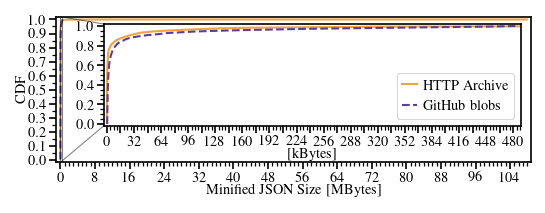

In [9]:
#matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth_acmsmall.mplstyle")
matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
matplotlib.use("inline")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 4 / 8,
)
matplotlib.pyplot.rc('axes', prop_cycle=matplotlib.pyplot.cycler(color=["#f1a340", "#5e3c99"], linestyle=["-", "--"]))

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

axins = ax.inset_axes(
    [0.1, 0.25, 0.88, 0.70],
    xlim=(-4000, 501000),
    xticks=numpy.arange(0, 501000, 16 * 1024),
    ylim=(-0.02, 1.02),
    yticks=numpy.arange(0, 1.1, 0.2),
)
axs = [ax, axins]
for dataset, in lf.select(["dataset"]).unique().sort("dataset", descending=True).collect().iter_rows():
    cdf_df = lf.filter(
        polars.col("dataset") == dataset
    ).group_by(["dataset", "json_size"]).agg(
        count=polars.col("json_size").count()
    ).sort("json_size").select(
        polars.col("dataset"),
        polars.col("json_size"),
        polars.cum_sum("count").alias("cum_sum") / polars.col("count").sum(),
    ).collect()
    for a in axs:
        a.plot(cdf_df["json_size"], cdf_df["cum_sum"], label=dataset)
    IPython.display.display(IPython.display.Markdown(dataset)) 
    IPython.display.display(IPython.display.Markdown(f"- max: {cdf_df['json_size'].max()} bytes"))
    if dataset == "HTTP Archive":
        github_max = lf.filter(polars.col("dataset") == "GitHub blobs").collect()["json_size"].max()
        quantile = cdf_df.filter(cdf_df["json_size"] <= github_max)
        IPython.display.display(IPython.display.Markdown(f"- GitHub max ({github_max} bytes) @ $q_{{{quantile["cum_sum"][-1]}}}$: {quantile["json_size"][-1]:.0f} bytes"))
        del quantile
    del cdf_df

ax.set_xlabel("Minified JSON Size [MBytes]")
ax.set_xlim((-1000 * 1024, 114000000))
ax.set_xticks(numpy.arange(0, 114000000, 8 * 1024 * 1024))
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1024 * 1024))
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024 / 1024:.0f}$"))
ax.set_ylabel("CDF")
ax.set_ylim((-0.02, 1.02))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))

axins.set_xlabel("[kBytes]")
axins.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(4 * 1024))
axins.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:.0f}$" if (pos % 2) == 0 else ""))
axins.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))

_, (lower_left, upper_left, lower_right, upper_right) = ax.indicate_inset_zoom(
    axins,
    edgecolor="black",
    linewidth=0.5,
)
lower_left.set_visible(True)
upper_left.set_visible(True)
lower_right.set_visible(False)
upper_right.set_visible(False)
axins.legend(loc="lower right")

filepath = JSON2CBOR_EVAL_DIR / "plots" / "json-sizes-cdf.pdf"
IPython.display.display(IPython.display.Markdown(f"#### [JSON Sizes]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)

### Taxonomy Determination Problems on GitHub

For some JSON files, the JavaScript-based tool by Viotti and Kinderkhedia was not able to read the file.
In our [analysis above](#Plot-Taxonomy), we use our own, adapted tool to fill out these gaps (ll. 20-29).
The code of this tool can be found in `utils`.

In [10]:
list_code(JSON2CBOR_EVAL_DIR.parent / "utils" / "taxonomy.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2023 TU Dresden
#
# Distributed under terms of the MIT license.


import argparse
import base64
import functools
import itertools
import json

import cbor2


def values(obj):
    if isinstance(obj, dict):
        return list(obj.values())
    elif isinstance(obj, list):
        return obj
    else:
        []


class EncodeCBORDict(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, bytes):
            return base64.b64encode(obj).decode()
        elif isinstance(obj, cbor2.CBORTag):
            return obj.value
        return super().default(obj)


def utf8size(obj):
    return len(json.dumps(obj, ensure_ascii=False, separators=(",", ":"), cls=EncodeCBORDict))


def byte_size(obj):
    if isinstance(obj, (dict, list)):
        return functools.reduce(
            lambda acc, size: {
                "scalar": acc["scalar"] + size["scalar"],
                "structural": acc["structural"] + size["structural"],
            },
            list(
                map(
                    byte_size,
                    values(obj),
                )
            )
            + [
                {
                    "scalar": 0,
                    "structural": (
                        (2 + max(len(obj), 1) - 1)
                        if isinstance(obj, list)
                        else len(obj.keys()) + utf8size(list(obj.keys()))
                    ),
                }
            ],
            {"scalar": 0, "structural": 0},
        )
    return {"scalar": utf8size(obj), "structural": 0}


def deep_values(obj):
    if isinstance(obj, (dict, list)):
        return functools.reduce(
            lambda acc, el: acc + deep_values(el), values(obj), [obj]
        )
    return [obj]


def height(obj):
    if isinstance(obj, (dict, list)):
        return 1 + max([0] + list(map(height, values(obj))))
    return 0


def level(obj, lvl):
    if lvl == 0:
        return [obj]
    elif isinstance(obj, (dict, list)):
        if lvl <= 1:
            return list(
                filter(
                    lambda el: not isinstance(el, (dict, list)),
                    values(obj),
                )
            )
        else:
            return functools.reduce(
                lambda acc, el: acc + level(el, lvl - 1),
                values(obj),
                [],
            )
    else:
        return []


def acc_byte_size(elements, size_keys=["scalar", "structural"]):
    return functools.reduce(
        lambda acc, size: acc + sum(size[k] for k in size_keys),
        map(lambda el: byte_size(el), elements),
        0,
    )


def level_analyze(obj, lvl):
    elements = level(obj, lvl)
    return {
        "count": len(elements),
        "size": acc_byte_size(elements),
    }


def is_deep_equal(left, right):
    if isinstance(left, cbor2.CBORTag):
        if not isinstance(right, cbor2.CBORTag):
            return False
        return left == right
    if isinstance(left, dict):
        if not isinstance(right, dict):
            return False
        elif len(left) != len(right):
            return False

        for key in left:
            if key not in right or not is_deep_equal(left[key], right[key]):
                return False

        return True
    elif isinstance(left, list):
        if not isinstance(right, list):
            return False
        elif len(left) != len(right):
            return False

        for index, value in enumerate(left):
            if not is_deep_equal(value, right[index]):
                return False

        return True
    return left == right


def unique_deep(objs):
    return functools.reduce(
        lambda acc, el: (
            acc + [el] if not any(is_deep_equal(item, el) for item in acc) else acc
        ),
        objs,
        []
    )


def analyze(obj):
    byte_sz = byte_size(obj)
    values = deep_values(obj)
    higt = height(obj)

    textual = list(filter(lambda el: isinstance(el, str), values)

Nevertheless, we analyse the reasons why the original tool errored and by how much certain GitHub users caused these errors below.

In [11]:
def nan_or_infinity(v):
    if isinstance(v, float) and numpy.isnan(v):
        return True
    return [float("inf"), float("-inf")]


def contains_nan_or_infinity(d):
    for key, value in d.items():
        if isinstance(value, list):
            return any(nan_or_infinity(v) for v in value)
        if isinstance(value, dict):
            return contains_nan_or_infinity(value)
        if nan_or_infinity(key) or nan_or_infinity(value):
            return True


def determine_missing_taxonomy(args):
    fname = args["json_filename"]
    with open(JSON2CBOR_EVAL_DIR / "jsons" / fname) as f:
        obj = json.load(f)
    tax = tuple(taxonomy.main(obj))
    if tax == ("str", "str", "str", "str"):
        tax = (
            "tier 1" if len(obj) < 100 else
            "tier 2" if len(obj) < 1000 else
            "tier 3",
            "textual",
            "non-redundant",
            "flat"
        )
    args["json_size_tier"] = tax[0]
    args["json_content_type"] = tax[1]
    args["json_redundancy"] = tax[2]
    args["json_structure"] = tax[3]

    if obj is None:
        args["problem"] = "flat null"
    elif isinstance(obj, dict):
        args["problem"] = (
            "dict contains Infinity or NaN"
            if contains_nan_or_infinity(obj)
            else "Other problem with dict"
        )
    elif isinstance(obj, list):
        args["problem"] = (
            "list contains Infinity or NaN"
            if any(nan_or_infinity(v) for v in obj)
            else "Other problem with list"
        )
    else:
        args["problem"] = f"flat {type(obj).__name__}"
    return args


lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "json2cbor_rpi3.csv.gz",
    separator=";"
).filter(
    polars.col("json_filename").str.starts_with("github/")
).with_columns(
    user=polars.col("json_filename").str.split("/").list.get(1)
)

taxonomy_problems = lf.filter(
    polars.col("json_size_tier").is_null()
).select(
    [
        "user",
        "json_filename",
        "json_size_tier",
        "json_content_type",
        "json_redundancy",
        "json_structure",
    ]
).with_columns(
    results=polars.struct(polars.all()).map_elements(
        determine_missing_taxonomy,
        return_dtype=polars.Struct(
            {
                k: polars.String
                for k in [
                    "user",
                    "json_filename",
                    "json_size_tier",
                    "json_content_type",
                    "json_redundancy",
                    "json_structure",
                    "problem",
                ]
            }
        )
    )
).select("results").unnest("results").sort(
    polars.col("user").str.to_lowercase(),
    polars.col("json_filename").str.to_lowercase(),
).collect()

IPython.display.display(IPython.display.Markdown("#### Reasons"))
with polars.Config(
    tbl_rows=taxonomy_problems.shape[0],
    fmt_str_lengths=taxonomy_problems["json_filename"].str.len_chars().max()
):
    IPython.display.display(taxonomy_problems)

IPython.display.display(IPython.display.Markdown("#### Problems Per User"))
user_objs = {
    row[0]: row[1]
    for row in lf.filter(
        polars.col("user").is_in(taxonomy_problems["user"].implode())
    ).group_by("user").agg(polars.col("json_filename").count()).collect().iter_rows()
}
user_errors = taxonomy_problems.group_by("user").agg(
    errors=polars.col("problem").count(),
).with_columns(
    objects=polars.col("user").replace_strict(user_objs)
).with_columns(
    error_rate=polars.col("errors") / polars.col("objects")
).select(["user", "errors", "error_rate"]).sort(["error_rate", "errors"], descending=True)
with polars.Config(
    tbl_rows=user_errors.shape[0],
    fmt_str_lengths=user_errors["user"].str.len_chars().max(),
    float_precision=3,
):
    IPython.display.display(user_errors)

#### Reasons

user,json_filename,json_size_tier,json_content_type,json_redundancy,json_structure,problem
str,str,str,str,str,str,str
"""ambethia""","""github/ambethia/katas/javascript/7-kyu/mumbling/fixtures.js""","""tier 1""","""structural""","""non-redundant""","""flat""","""flat null"""
"""arfon""","""github/arfon/astropy-lambda/astropy/vo/validator/tests/data/conesearch_good.json""","""tier 3""","""textual""","""non-redundant""","""nested""","""dict contains Infinity or NaN"""
"""avsej""","""github/avsej/gson.rb/test/okjson/t/decode-bignum-e.json""","""tier 1""","""numeric""","""non-redundant""","""flat""","""list contains Infinity or NaN"""
"""awt""","""github/awt/litter/test/fixtures/record.json""","""tier 1""","""textual""","""non-redundant""","""flat""","""flat str"""
"""devinus""","""github/devinus/poison/bench/data/utf-8-escaped.json""","""tier 3""","""textual""","""non-redundant""","""flat""","""flat str"""
"""devinus""","""github/devinus/poison/bench/data/utf-8-unescaped.json""","""tier 3""","""textual""","""non-redundant""","""flat""","""flat str"""
"""elmarco""","""github/elmarco/libvirt/tests/nodeinfodata/linux-test4/cpu/cpu15/topology/thread_siblings""","""tier 1""","""numeric""","""non-redundant""","""flat""","""flat int"""
"""gabriel""","""github/gabriel/yajl-objc/Tests/Samples/overflow.json""","""tier 1""","""numeric""","""non-redundant""","""flat""","""dict contains Infinity or NaN"""
"""harningt""","""github/harningt/luajson/tests/test/fail_strict/whitespace_before_value.json""","""tier 1""","""textual""","""non-redundant""","""flat""","""flat str"""


#### Problems Per User

user,errors,error_rate
str,u64,f64
"""Val""",1,1.000
"""harningt""",4,0.444
"""scottag99""",1,0.250
"""manuel""",1,0.250
"""rgcottrell""",1,0.200
"""awt""",1,0.167
"""arfon""",1,0.111
"""svoop""",1,0.100
"""paulsmith""",1,0.100


### GitHub Users and Taxonomy

Below we analysed if there is a certain correlation between users and taxonomy, i.e., if certain taxonomies gather at certain users. Our analysis shows that there is no distinct correlation.

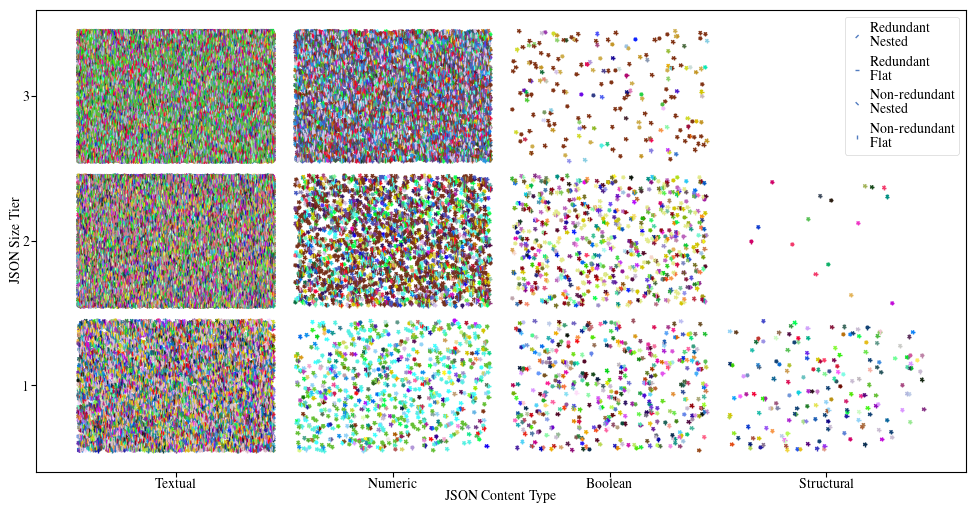

In [12]:
users = {
    k: v
    for v, k in enumerate(
        sorted(
            lf.filter(polars.col("user") != "github").collect()["user"].unique(),
            key=lambda x: x.lower()
        )
    )
}


def sorted_name_to_color(name):
    rgb = int(users[name] * (0xffffff / len(users)))
    return f"#{int(rgb):06x}"


matplotlib.rcParams["figure.figsize"] = (12, 6)
matplotlib.rcParams["legend.fontsize"] = "medium"
matplotlib.rcParams["axes.labelsize"] = "medium"
matplotlib.rcParams["xtick.labelsize"] = "medium"
matplotlib.rcParams["ytick.labelsize"] = "medium"

CTS = ["Textual", "Numeric", "Boolean", "Structural"]
MARKER = {
    ("Redundant", "Nested"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(45)),
    ("Non-redundant", "Nested"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(135)),
    ("Redundant", "Flat"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(0)),
    ("Non-redundant", "Flat"): matplotlib.markers.MarkerStyle("_", transform=matplotlib.transforms.Affine2D().rotate_deg(90)),
}


df = lf.filter(polars.col("user") != "github").join(
    taxonomy_problems.lazy(),
    on=["user", "json_filename"],
    how="left",
).with_columns(
    json_size_tier=polars.when(
        polars.col("json_size_tier").is_null()
    ).then(
        polars.col("json_size_tier_right").str.strip_prefix("tier ").str.to_integer()
    ).otherwise(
        polars.col("json_size_tier")
    ),
    json_content_type=polars.when(
        polars.col("json_content_type").is_null()
    ).then(
        polars.col("json_content_type_right").str.to_titlecase()
    ).otherwise(
        polars.col("json_content_type")
    ),
    json_redundancy=polars.when(
        polars.col("json_redundancy").is_null()
    ).then(
        polars.col("json_redundancy_right").str.to_titlecase()
    ).otherwise(
        polars.col("json_redundancy")
    ),
    json_structure=polars.when(
        polars.col("json_structure").is_null()
    ).then(
        polars.col("json_structure_right").str.to_titlecase()
    ).otherwise(
        polars.col("json_structure")
    ),
).select(
    ["user", "json_size_tier", "json_content_type", "json_redundancy", "json_structure"]
).with_columns(
    user_color=polars.col("user").map_elements(
        sorted_name_to_color,
        return_dtype=polars.String,
    ),
    json_content_type_val=polars.when(
        polars.col("json_content_type").is_not_null()
    ).then(
        polars.col("json_content_type").map_elements(
            lambda x: float(CTS.index(x)) + numpy.random.uniform(-0.45, 0.45),
            return_dtype=polars.Float64,
        )
    ),
    json_size_tier_val=polars.when(
        polars.col("json_size_tier").is_not_null()
    ).then(
        polars.col("json_size_tier").map_elements(
            lambda x: float(x) + numpy.random.uniform(-0.45, 0.45),
            return_dtype=polars.Float64,
        )
    ),
).collect()

for red in ["Redundant", "Non-redundant"]:
    for struct in ["Nested", "Flat"]:
        matplotlib.pyplot.scatter(
            df["json_content_type_val"],
            df["json_size_tier_val"],
            c=df["user_color"],
            marker=MARKER[red, struct],
            label=f"{red}\n{struct}"
        )

matplotlib.pyplot.legend(loc="upper right")
matplotlib.pyplot.xlabel("JSON Content Type")
matplotlib.pyplot.xticks(range(len(CTS)), CTS)
matplotlib.pyplot.ylabel("JSON Size Tier")
matplotlib.pyplot.yticks(range(1, 4))
matplotlib.pyplot.show()

user_html = []
for user, color in df.select(["user", "user_color"]).unique().sort(
    polars.col("user").str.to_lowercase(),
).iter_rows():
    user_html.append(f'<span style="color:{color}">{user} ({color})</span>')
IPython.display.display(IPython.display.HTML(", ".join(user_html)))

## GitHub Filenames

Here, we generate the analysis of filenames in our dataset. This results in Figure 5 in our paper.

In [13]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth.mplstyle")

matplotlib.rcParams["figure.figsize"] = (
    (matplotlib.rcParams["figure.figsize"][0] * 9) / 10,
    (matplotlib.rcParams["figure.figsize"][0] * 2) / 10,
)

lf = polars.scan_csv(
    pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz",
    separator=";"
).filter(
    polars.col("json_filename").str.starts_with("github/")
    & (polars.col("github_type") == "stored_json")
).with_columns(
    json_filename=polars.col("json_filename").str.split("/").list.last()
).group_by("json_filename").agg(
    count=polars.col("json_filename").count()
).with_columns(
    json_filename=polars.when(
        polars.col("count") < 2
    ).then(
        polars.lit("Unique names")
    ).otherwise(polars.col("json_filename"))
).group_by("json_filename").agg(
    count=polars.col("count").sum()
).with_columns(
    percentage=polars.col("count") / polars.col("count").sum() * 100
).sort("count", descending=True).rename(
    {
        "json_filename": "Filename",
    }
).rename(lambda t: t.title())

print(
    lf.filter(polars.col("Percentage") >= 0.5).collect().to_pandas().to_latex(
        float_format=lambda x: rf"{x:0.1f}\%",
        index=False
    )
)

lf.with_columns(
    polars.col("Percentage").map_elements(
        lambda s: f"{s:.3g}%",
        return_dtype=polars.String,
    )
).collect()

\begin{tabular}{lrr}
\toprule
Filename & Count & Percentage \\
\midrule
Unique names & 48498 & 39.3\% \\
package.json & 19484 & 15.8\% \\
package-lock.json & 3723 & 3.0\% \\
Contents.json & 3712 & 3.0\% \\
http-response.json & 1657 & 1.3\% \\
bower.json & 1266 & 1.0\% \\
manifest.json & 1210 & 1.0\% \\
metadata.json & 1206 & 1.0\% \\
settings.json & 1177 & 1.0\% \\
info.json & 1089 & 0.9\% \\
composer.json & 760 & 0.6\% \\
hawk-post.json & 723 & 0.6\% \\
config.json & 695 & 0.6\% \\
\bottomrule
\end{tabular}



Filename,Count,Percentage
str,u64,str
"""Unique names""",48498,"""39.3%"""
"""package.json""",19484,"""15.8%"""
"""package-lock.json""",3723,"""3.02%"""
"""Contents.json""",3712,"""3.01%"""
"""http-response.json""",1657,"""1.34%"""
…,…,…
"""Test-Ubuntu17-GCC-Golo-GPU-Qua…",2,"""0.00162%"""
"""3327.json""",2,"""0.00162%"""
"""5521.json""",2,"""0.00162%"""


### Plot bar chart

This requires the cell above to be executed beforehand.

#### [Percentage of Common JSON File Names](03_json2cbor_eval/plots/json-names-percentage.pdf)

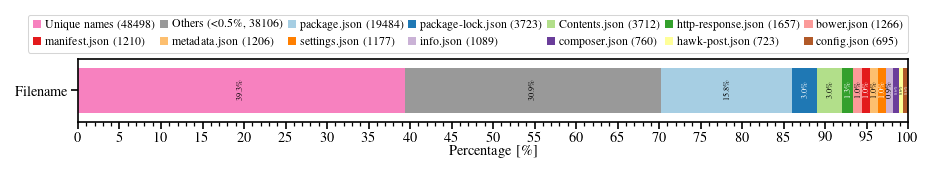

In [14]:
def grayout(color, amount):
    c = matplotlib.colors.rgb_to_hsv(color)
    return matplotlib.colors.hsv_to_rgb((c[0], c[1], amount * (c[2])))


def color_func(word, *args, **kwargs):
    if word in STATIC_COLORMAP:
        return STATIC_COLORMAP[word]
    chash = hash(word)
    clen = len(COLORMAP)
    return OTHERS_COLOR


COLORMAP = [
    "#{:02x}{:02x}{:02x}".format(
        *tuple(int(i * 255) for i in grayout(c, 0.75))
    )
    for c in matplotlib.colormaps["Paired"].colors
]
STATIC_COLORMAP = {
    "package.json": "#a6cee3",
    "package-lock.json": "#1f78b4",
    "Contents.json": "#b2df8a",
    "http-response.json": "#33a02c",
    "bower.json": "#fb9a99",
    "manifest.json": "#e31a1c",
    "metadata.json": "#fdbf6f",
    "settings.json": "#ff7f00",
    "info.json": "#cab2d6",
    "composer.json": "#6a3d9a",
    "hawk-post.json": "#ffff99",
    "config.json": "#b15928",
}
OTHERS_COLOR = "#999999"
THRESHOLD = 0.5

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] / 4,
)
matplotlib.rcParams["legend.fontsize"] = "xx-small"
matplotlib.rcParams["legend.columnspacing"] = 0.4
matplotlib.rcParams["legend.handletextpad"] = 0.3
matplotlib.rcParams["legend.handlelength"] = 0.7

colors = {k: v for k, v in STATIC_COLORMAP.items()}
colors["Others"] = OTHERS_COLOR
colors["Unique names"] = "#f781bf"

names = polars.concat(
    [
        lf.filter(polars.col("Percentage") >= THRESHOLD),
        lf.filter(polars.col("Percentage") < THRESHOLD).with_columns(
            polars.lit("Others").alias("Filename")
        ).group_by("Filename").sum()
    ]
).with_columns(
    sort_idx=polars.when(
        polars.col("Filename") == "Unique names"
    ).then(
        102.0
    ).otherwise(
        polars.when(
            polars.col("Filename") == "Unique names"
        ).then(
            101.0
        ).otherwise(polars.col("Percentage"))
    )
).sort("sort_idx", descending=True).select(
    ["Filename", "Count", "Percentage"]
).with_columns(
    bottom=polars.col("Percentage").cum_sum() - polars.col("Percentage")
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

for filename, count, percentage, bottom in names.collect().iter_rows():
    ax.barh(
        0,
        percentage,
        left=bottom,
        label=(
            fr"{filename} (<{THRESHOLD:.1f}\%, {count})"
            if filename == "Others"
            else f"{filename} ({count})"
        ),
        height=0.70,
        color=colors[filename],
    )

ax.set_xlabel(r"Percentage [\%]")
ax.set_xticks(range(0, 110, 5))
ax.set_xlim((0, 100))
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))

ax.set_yticks([0], [r"Filename"])
ax.set_ylim((-0.5, 0.5))

offset = 0
for i, perc in enumerate(names.collect()["Percentage"]):
    if perc:
        matplotlib.pyplot.text(
            (perc / 2) + offset,
            0,
            rf"${perc:.1f}\%$",
            ha="center",
            va="center",
            fontsize=4 if perc >= 3 else (4 if perc >= 0.8 else 2),
            rotation=90,
            color="white" if i > 1 and (i % 2) == 1 else "black",
        )
    offset += perc

def flip(items, ncol):
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])

handles, labels = ax.get_legend_handles_labels()
matplotlib.pyplot.legend(
    loc="lower center",
    bbox_to_anchor=(0.47, 1.0),
    ncol=7,
    handles=flip(handles, 7),
    labels=flip(labels, 7),
)

filepath = OUTPUT_PATH / "json-names-percentage.pdf"
IPython.display.display(
    IPython.display.Markdown(
        f"#### [Percentage of Common JSON File Names]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)

## Compression: JSON to CBOR

### Runtime
This covers our evaluation in Section 3.3 “Encoding/Decoding Runtime” and, for `json2cbor_rpi3.csv.gz`, results in the plots shown in Figure 6 and Table 1 of our paper.

#### RPi3
**Iterations:** 100

##### [Serializer](03_json2cbor_eval/plots/json2cbor-times_dumps_rpi3.pdf)

<Figure size 714.13x55.1696 with 0 Axes>

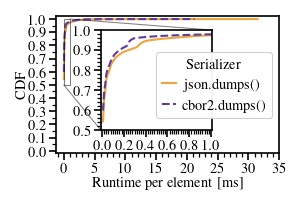

##### [Parser](03_json2cbor_eval/plots/json2cbor-times_loads_rpi3.pdf)

<Figure size 191.819x118.55 with 0 Axes>

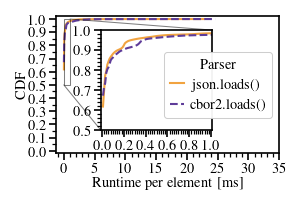

Function,mean [ms],std. [ms],min. [ms],median [ms],max. [ms]
str,f64,f64,f64,f64,f64
"""json.dumps()""",0.124738,0.629026,0.000475,0.008707,31.504779
"""cbor2.dumps()""",0.089524,0.435252,0.000556,0.007243,21.247815
"""json.loads()""",0.073572,0.328773,0.000208,0.006086,22.752604
"""cbor2.loads()""",0.105306,0.474716,0.000458,0.004388,24.623884


\begin{tabular}{lrrrrr}
\toprule
Function & mean [ms] & std. [ms] & min. [ms] & median [ms] & max. [ms] \\
\midrule
json.dumps() & 0.12 & 0.63 & $4.8 \times 10^{-4}$ & $8.7 \times 10^{-3}$ & 31.5 \\
cbor2.dumps() & 0.09 & 0.44 & $5.6 \times 10^{-4}$ & $7.2 \times 10^{-3}$ & 21.2 \\
json.loads() & 0.07 & 0.33 & $2.1 \times 10^{-4}$ & $6.1 \times 10^{-3}$ & 22.8 \\
cbor2.loads() & 0.11 & 0.47 & $4.6 \times 10^{-4}$ & $4.4 \times 10^{-3}$ & 24.6 \\
\bottomrule
\end{tabular}



#### Dual AMD EPYC 7702
**Iterations:** 1000

##### [Serializer](03_json2cbor_eval/plots/json2cbor-times_dumps_epyc7702.pdf)

<Figure size 191.819x118.55 with 0 Axes>

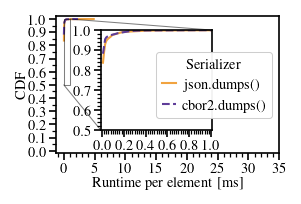

##### [Parser](03_json2cbor_eval/plots/json2cbor-times_loads_epyc7702.pdf)

<Figure size 191.819x118.55 with 0 Axes>

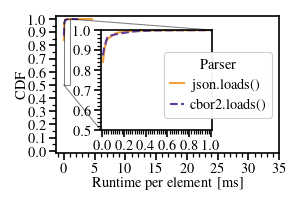

Function,mean [ms],std. [ms],min. [ms],median [ms],max. [ms]
str,f64,f64,f64,f64,f64
"""json.dumps()""",0.012493,0.070485,0.000038,0.00093,4.857702
"""cbor2.dumps()""",0.00938,0.046833,0.000076,0.000676,2.315656
"""json.loads()""",0.010999,0.044675,0.000023,0.000909,4.577323
"""cbor2.loads()""",0.011029,0.051132,0.000049,0.000497,2.328639


\begin{tabular}{lrrrrr}
\toprule
Function & mean [ms] & std. [ms] & min. [ms] & median [ms] & max. [ms] \\
\midrule
json.dumps() & 0.01 & 0.07 & $3.8 \times 10^{-5}$ & $9.3 \times 10^{-4}$ & 4.86 \\
cbor2.dumps() & $9.4 \times 10^{-3}$ & 0.05 & $7.6 \times 10^{-5}$ & $6.8 \times 10^{-4}$ & 2.32 \\
json.loads() & 0.01 & 0.04 & $2.3 \times 10^{-5}$ & $9.1 \times 10^{-4}$ & 4.58 \\
cbor2.loads() & 0.01 & 0.05 & $4.9 \times 10^{-5}$ & $5.0 \times 10^{-4}$ & 2.33 \\
\bottomrule
\end{tabular}



In [15]:
PLATFORM_TITLE = {
    "epyc7702": "Dual AMD EPYC 7702",
    "rpi3": "RPi3",
}
METHOD_NAME = {
    "json_dumps_time": "json.dumps()",
    "cbor_dumps_time": "cbor2.dumps()",
    "json_loads_time": "json.loads()",
    "cbor_loads_time": "cbor2.loads()",
}


lf = polars.concat(
    polars.scan_csv(
        JSON2CBOR_EVAL_DIR / file,
        separator=";",
    ).with_columns(
        platform=polars.lit(re.search(r"json2cbor_([^.]+)\.csv\.gz", file)[1])
    )
    for file in [
        "json2cbor_rpi3.csv.gz",
        "json2cbor_epyc7702.csv.gz",
    ]
).filter(
    #(polars.col("github_type") == "stored_json")
    # & 
    polars.col("json_filename").str.starts_with("github/")
).with_columns(
    *[
        # calculate runtime per iteration and element in ms
        (
            polars.col(metric)
            / polars.col("iterations")
            / polars.col("json_elements")
            * 1000
        ).alias(METHOD_NAME[metric])
        for metric in [
            "json_dumps_time",
            "cbor_dumps_time",
            "json_loads_time",
            "cbor_loads_time",
        ]
    ]
)

for platform, in lf.select(["platform"]).unique().sort("platform", descending=True).collect().iter_rows():
    df = lf.filter(
        polars.col("platform") == platform
    ).collect()
    IPython.display.display(
        IPython.display.Markdown(f"#### {PLATFORM_TITLE[platform]}\n**Iterations:** {df["iterations"].min()}")
    )
 
    xmax = 31 # if platform == "rpi3" else 610
    xsteps = 5

    for method_title, method in [("Serializer", "dumps"), ("Parser", "loads")]:
        matplotlib.pyplot.gcf()
        matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn_ieeetran.mplstyle")
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0],
            matplotlib.rcParams["figure.figsize"][1],
        )
        matplotlib.rcParams["legend.framealpha"] = 0.95
        
        fig = matplotlib.pyplot.figure(
            figsize=matplotlib.rcParams["figure.figsize"],
            dpi=150,
        )
        ax = matplotlib.pyplot.gca()
        axs = [ax]
        axins = None
        
        if platform in ["rpi3", "epyc7702"]:
            axins = ax.inset_axes(
                [0.2, 0.17, 0.5, 0.73],
                xlim=(-0.01, 1.01),
                xticks=numpy.arange(0, 1.2, 0.2),
                ylim=(0.5, 1.0),
                yticks=numpy.arange(0.5, 1.02, 0.1),
            )
            axs.append(axins)
    
    
        plot_cdf(
            axs,
            df[f"json.{method}()"],
            f"json.{method}()",
            {"color": "#f1a340"},
        )
        plot_cdf(
            axs,
            df[f"cbor2.{method}()"],
            f"cbor2.{method}()",
            {"color": "#5e3c99", "linestyle": "--"},
        )
        ax.set_xlabel("Runtime per element [ms]")
        ax.set_ylabel("CDF")
        ax.set_xlim((0 - (xsteps / 4), xmax + (xsteps / 4)))
        ax.set_xticks(numpy.arange(0, xmax + xsteps, xsteps))
        ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(xsteps / 5))
        ax.set_ylim((-0.02, 1.02))
        ax.set_yticks(numpy.arange(0, 1.1, 0.1))
        ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
    
        if axins:
            ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=0.5)
            axins.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))
            axins.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))
        
        ax.legend(title=method_title, loc="center right")
        filepath = OUTPUT_PATH / f"json2cbor-times_{method}_{platform}.pdf"
        # matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
        IPython.display.display(
            IPython.display.Markdown(
                f"##### [{method_title}]({str(filepath.relative_to(pathlib.Path.cwd()))})"
            )
        )
        matplotlib.pyplot.show()
    stats = df.select(
        ["json.dumps()", "cbor2.dumps()", "json.loads()", "cbor2.loads()"]
    ).lazy()
    stats = polars.concat(
        [
            stats.select(
                [
                    polars.lit(f"{agg_name} [ms]").alias("header")
                ] + [
                    agg(col)
                    for col in stats.collect_schema().names()
                ]
            )
            for agg, agg_name in [
                (polars.mean, "mean"),
                (polars.std, "std."),
                (polars.min, "min."),
                (polars.median, "median"),
                (polars.max, "max."),
            ]
        ]
    ).collect().transpose(
        include_header=True,
        header_name="Function",
        column_names="header",
    )

    IPython.display.display(stats)
    print(
        stats.to_pandas().to_latex(
            float_format=lambda x: re.sub(
                r"(\d+.\d+)e([+-])0*([1-9]\d*)", r"$\1 \\times 10^{\2\3}$",
                f"{x:.1e}" if x < 0.01 else (f"{x:.1f}" if x > 10 else f"{x:.2f}")
            ),
            index=False
        )
    )

### Compression

This contains our analysis for section 3.4 “Compression Gain and Byte Savings” of our paper.


#### Byte Savings

This plots byte savings $b$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$b = \text{Minified JSON size} - \text{CBOR size}\$


##### **HTTP Archive**

\# savings $< 0$: 46

###### [`json2cbor-savings_harch.pdf`](03_json2cbor_eval/plots/json2cbor-savings_harch.pdf)

<Figure size 191.819x118.55 with 0 Axes>

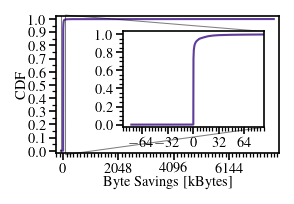

Objects,size [#],mean [bytes],std. [bytes],min. [bytes],median [bytes],max. [bytes]
str,f64,f64,f64,f64,f64,f64
"""GZipped JSON""",120929.0,15622.215804,414634.908166,-24976.0,86.0,9.7836804e7
"""Simple CBOR""",120929.0,2499.141744,41266.54478,-79525.0,43.0,7.988026e6
"""Deterministic CBOR""",120929.0,2522.874083,41658.018173,-67243.0,43.0,7.990306e6


##### **GitHub**

Objects,size [#],mean [bytes],std. [bytes],min. [bytes],median [bytes],max. [bytes]
str,f64,f64,f64,f64,f64,f64
"""GZipped JSON (All)""",287636.0,0.0,0.0,0.0,0.0,0.0
"""Simple CBOR (All)""",287636.0,1600.262189,6055.570198,-194055.0,84.0,186117.0
"""Deterministic CBOR (All)""",287636.0,1631.848388,6088.681709,-146817.0,85.0,186117.0
"""GZipped JSON (Stored JSONs)""",123271.0,0.0,0.0,0.0,0.0,0.0
"""Simple CBOR (Stored JSONs)""",123271.0,1730.729361,6676.165749,-194055.0,101.0,186117.0
"""Deterministic CBOR (Stored JSO…",123271.0,1796.933902,6731.357721,-146817.0,104.0,186117.0


###### [`json2cbor-blobs-savings.pdf`](03_json2cbor_eval/plots/json2cbor-blobs-savings.pdf)

<Figure size 191.819x118.55 with 0 Axes>

<Figure size 287.728x177.826 with 0 Axes>

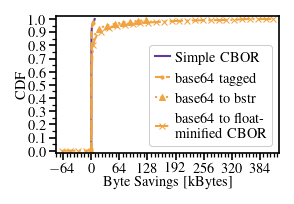

Objects,size [#],mean [bytes],std. [bytes],min. [bytes],median [bytes],max. [bytes]
str,f64,f64,f64,f64,f64,f64
"""Simple CBOR""",128643.0,379.895229,1145.025881,20.0,44.0,7982.0
"""base64 tagged""",128643.0,393.895229,1145.025881,34.0,58.0,7996.0
"""base64 to bstr""",128643.0,6177.149406,19471.78346,45.0,455.0,135440.0
"""base64 to float- minified CBOR""",123306.0,12128.981193,42328.312588,-68000.0,752.0,424695.0



#### Gain

This plots gain $g$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$g = \frac{b}{\text{Minified JSON size}}\$


##### **HTTP Archive**

\# gain $< 0$: 46

###### [`json2cbor-gain_harch.pdf`](03_json2cbor_eval/plots/json2cbor-gain_harch.pdf)

<Figure size 191.819x118.55 with 0 Axes>

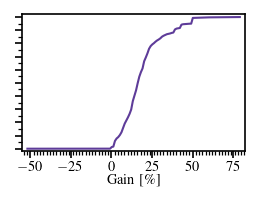

Objects,size [#],mean [%],std. [%],min. [%],median [%],max. [%]
str,f64,f64,f64,f64,f64,f64
"""GZipped JSON""",1.20929e7,-192.22537,8389.017823,-2.4976e6,26.616915,100.0
"""Simple CBOR""",1.20929e7,18.793899,12.786072,-52.853231,16.226602,80.0
"""Deterministic CBOR""",1.20929e7,18.905649,12.773208,-52.128655,16.605166,80.0


##### **GitHub**

Objects,size [#],mean [%],std. [%],min. [%],median [%],max. [%]
str,f64,f64,f64,f64,f64,f64
"""GZipped JSON (All)""",2.87636e7,0.0,0.0,0.0,0.0,0.0
"""Simple CBOR (All)""",2.87636e7,8.523013,8.029567,-125.0,5.177788,81.789932
"""Deterministic CBOR (All)""",2.87636e7,8.765595,8.338177,-125.0,5.276382,81.789932
"""GZipped JSON (Stored JSONs)""",1.23271e7,0.0,0.0,0.0,0.0,0.0
"""Simple CBOR (Stored JSONs)""",1.23271e7,15.289788,8.140987,-125.0,14.418399,81.789932
"""Deterministic CBOR (Stored JSO…",1.23271e7,15.829086,8.41362,-125.0,14.618644,81.789932


###### [`json2cbor-blobs-gain.pdf`](03_json2cbor_eval/plots/json2cbor-blobs-gain.pdf)

<Figure size 191.819x118.55 with 0 Axes>

<Figure size 287.728x177.826 with 0 Axes>

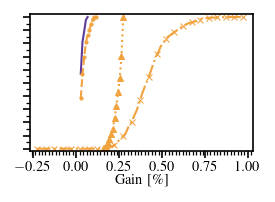

Objects,size [#],mean [%],std. [%],min. [%],median [%],max. [%]
str,f64,f64,f64,f64,f64,f64
"""Simple CBOR""",1.28643e7,2.782775,1.161486,1.615382,2.428658,7.482993
"""base64 tagged""",1.28643e7,3.909777,2.244086,1.618228,3.220433,12.244898
"""base64 to bstr""",1.28643e7,24.535792,2.76574,14.364641,25.42559,27.412931
"""base64 to float- minified CBOR""",1.23306e7,41.975402,12.040645,-23.785538,40.762762,98.76753


In [16]:
SLIDE_VERSION = False       # set to true for styling for slide set
ONLY_PAPER = True           # set to False to plot with filters based on taxonomy
# LABEL_GAIN_YTICKS = True    # set to False if you want to omit the labels of the y-axis (like in the paper)
LABEL_GAIN_YTICKS = False

INTRO_TEXT = {
    "savings": r"""
#### Byte Savings

This plots byte savings $b$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$b = \text{Minified JSON size} - \text{CBOR size}\$
""",
    "gain": r"""
#### Gain

This plots gain $g$ with “Minified JSON size” being the size of the JSON object after removal of structural whitespaces in bytes and “CBOR size” being the size of the CBOR object in bytes.

\$g = \frac{b}{\text{Minified JSON size}}\$
"""
}
METRIC_UNIT = {
    "savings": "bytes",
    "gain": "%",
}
METRIC_XAXIS_LABEL = {
    "savings": "Byte Savings [kBytes]",
    "gain": r"Gain [\%]",
}

DATASET_TITLE = {
    "github": "GitHub",
    "harch": "HTTP Archive",
}
DATASET_SUFFIX = {
    "github": "",
    "harch": "_harch",
}
SIZES = [
    "cbor_simple",
    "cbor_canon",
    "json_gz",
    "cbor_base64_tagged",
    "cbor_base64_bin",
    "cbor_base64_cbor",
]
SIZES_LABEL = {
    "cbor_simple": {
        ("github", None): "Simple CBOR (All)",
        ("github", "stored_json"): "Simple CBOR (Stored JSONs)",
        ("github", "github_api_blob"): "Simple CBOR",
        ("harch", "stored_json"): "Simple CBOR",
    },
    "cbor_canon": {
        ("github", None): "Deterministic CBOR\n(All)",
        ("github", "stored_json"): "Deterministic CBOR\n(Stored JSONs)",
        ("harch", "stored_json"): "Deterministic CBOR",
    },
    "json_gz": {
        ("github", None): "GZipped JSON (All)",
        ("github", "stored_json"): "GZipped JSON (Stored JSONs)",
        ("harch", "stored_json"): "GZipped JSON",
    },
    "cbor_base64_tagged": {
        ("github", "github_api_blob"): "base64 tagged",
    },
    "cbor_base64_bin": {
        ("github", "github_api_blob"): "base64 to bstr",
    },
    "cbor_base64_cbor": {
        ("github", "github_api_blob"): "base64 to float-\nminified CBOR",
    },
}
SIZES_STYLE = {
    "cbor_simple": {
        ("github", None): {"color": "#5e3c99"},
        ("github", "stored_json"): {"color": "#5e3c99", "linestyle": "--"},
        ("github", "github_api_blob"): {"color": "#5e3c99"},
        ("harch", "stored_json"): {"color": "#5e3c99"},
    },
    "cbor_canon": {
        ("github", None): {"color": "#f1a340", "linestyle": "--"},
        ("github", "stored_json"): {"color": "#f1a340", "linestyle": ":"},
    },
    "cbor_base64_tagged": {
        ("github", "github_api_blob"): {"color": "#f1a340", "linestyle": "--", "marker": "."},
    },
    "cbor_base64_bin": {
        ("github", "github_api_blob"): {"color": "#f1a340", "linestyle": ":", "marker": "^"},
    },
    "cbor_base64_cbor": {
        ("github", "github_api_blob"): {
            "color": "#f1a340",
            "linestyle": "-.",
            "marker": "x",
        },
    },
}
MARKEVERY = {
    ("gain", "cbor_base64_cbor"): lambda _: 5,
    ("savings", "cbor_base64_tagged"): lambda c: int(c / (7.05 * 4.5)),
    ("savings", "cbor_base64_bin"): lambda c: int(c / 7.05),
    ("savings", "cbor_base64_cbor"): lambda c: int(c / 7.05),
}
TIER_READABLE = [
    r"All sizes",
    r"Size tier 1 ($<$100 bytes)",
    r"Size tier 2 ($<$1000 bytes)",
    r"Size tier 3 ($\geq$1000 bytes)",
]

matplotlib.pyplot.close("all")
if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullslide.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] * 0.8,
    )
    matplotlib.use("pgf")
    matplotlib.rcParams["legend.labelspacing"] = 0.3
else:
    # matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column.mplstyle")
    # matplotlib.rcParams["figure.figsize"] = (
    #     matplotlib.rcParams["figure.figsize"][0] * 1.16,
    #     matplotlib.rcParams["figure.figsize"][1] / 2
    # )
    #matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn_acm.mplstyle")
    #matplotlib.rcParams["figure.figsize"] = (
    #    matplotlib.rcParams["figure.figsize"][0] * 1.11,
    #    # matplotlib.rcParams["figure.figsize"][1] * 2
    #    matplotlib.rcParams["figure.figsize"][1]
    #)
    # matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_acmsmall.mplstyle")
    # matplotlib.rcParams["figure.figsize"] = (
    #     matplotlib.rcParams["figure.figsize"][0] * 1.06,
    #     matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
    # )
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_halfcolumn_ieeetran.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0],
        matplotlib.rcParams["figure.figsize"][1],
    )
    matplotlib.use("inline")


lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "json2cbor_epyc7702.csv.gz",
    separator=";",
    schema_overrides={
        f"{tgt}_size": polars.UInt64 for tgt in (["json"] + SIZES)
    }
).with_columns(
    dataset=polars.col("json_filename").str.split("/").list.first(),
).with_columns(
   **{
       f"{tgt}_savings": polars.col("json_size").cast(polars.Int64) - polars.col(f"{tgt}_size").cast(polars.Int64)
       for tgt in SIZES
   }
).with_columns(
    **{
        f"{tgt}_gain": polars.col(f"{tgt}_savings") / polars.col("json_size")
        for tgt in SIZES
    }
).select(
    ["dataset", "github_type", "json_size_tier", "json_content_type", "json_redundancy", "json_structure"] + [
        f"{tgt}_size" for tgt in (["json"] + SIZES)
    ] + [
        f"{tgt}_savings" for tgt in SIZES
    ] + [
        f"{tgt}_gain" for tgt in SIZES
    ]
)

for metric in ["savings", "gain"]:
    IPython.display.display(
        IPython.display.Markdown(INTRO_TEXT[metric])
    )

    for dataset, in lf.select(["dataset"]).unique().sort("dataset", descending=True).collect().iter_rows():
        IPython.display.display(IPython.display.Markdown(f"##### **{DATASET_TITLE[dataset]}**"))
        for size_tier_nr, size_tier in enumerate(TIER_READABLE):
            size_filter = polars.col("dataset") == dataset
            if size_tier_nr == 0:
                tier_f = ""
            else:
                size_filter &= (polars.col("json_size_tier") == size_tier_nr)
                tier_f = f"-t{size_tier_nr}"
                
            entries = lf.filter(size_filter).select(polars.len()).collect().item()
            if entries == 0:
                continue
            if ONLY_PAPER and size_tier_nr != 0:
                continue
            elif not ONLY_PAPER:
                IPython.display.display(
                    IPython.display.Markdown(f"##### {size_tier} ({entries})")
                )
            
            for ctype in ["All", "Textual", "Numeric", "Boolean", "Structural"]:
                type_filter = size_filter
                if ctype == "All":
                    ctype = "All content types"
                    type_f = ""
                else:
                    type_filter &= (polars.col("json_content_type") == ctype)
                    type_f = f"-{ctype.lower()}"
                    
                entries = lf.filter(type_filter).select(
                    polars.len()
                ).collect().item()
                if entries == 0:
                    continue
                if ONLY_PAPER and ctype != "All content types":
                    continue
                elif not ONLY_PAPER:
                    IPython.display.display(
                        IPython.display.Markdown(f"###### **{ctype} ({entries})**")
                    )

                for red in ["Both", "Redundant", "Non-redundant"]:
                    red_filter = type_filter
                    if red == "Both":
                        red = "Both redundancies"
                        red_f = ""
                    else:
                        red_filter &= (polars.col("json_redundancy") == red)
                        red_f = f"-{red.lower()}"

                    entries = lf.filter(red_filter).select(
                        polars.len()
                    ).collect().item()
                    if entries == 0:
                        continue
                    if ONLY_PAPER and red != "Both redundancies":
                        continue
                    elif not ONLY_PAPER:
                        IPython.display.display(
                            IPython.display.Markdown(f"###### {red} ({entries})")
                        )

                    for struct in ["Both", "Flat", "Nested"]:
                        struct_filter = red_filter
                        if struct == "Both":
                            struct = "Both structures"
                            struct_f = ""
                        else:
                            struct_filter &= (polars.col("json_structure") == struct)
                            struct_f = f"-{struct.lower()}"
    
                        set_lf = lf.filter(struct_filter)
                        entries = set_lf.select(
                            polars.len()
                        ).collect().item()
                        if entries == 0:
                            continue
                        if ONLY_PAPER and struct != "Both structures":
                            continue
                        elif not ONLY_PAPER:
                            IPython.display.display(
                                IPython.display.Markdown(f"###### *{struct} ({entries})*")
                            )
                        matplotlib.pyplot.clf()
                        fig = matplotlib.pyplot.figure(
                            figsize=matplotlib.rcParams["figure.figsize"],
                            dpi=150,
                        )
                        ax = matplotlib.pyplot.gca()

                        ax.set_xlabel(METRIC_XAXIS_LABEL[metric])
                        
                        if metric == "savings":
                            ax.set_xlim((-256 * 1024, 8000 * 1024))
                            ax.set_xticks(numpy.arange(-0 * 1024, 8000 * 1024, (2 *1024) * 1024))
                            ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(128 * 1024))
                            ax.xaxis.set_major_formatter(
                                matplotlib.ticker.FuncFormatter(
                                    lambda x, pos: f"${x / 1024:0.0f}$"
                                )
                            )
                        elif metric == "gain":
                            if dataset == "harch":
                                ax.set_xlim((-0.55, 0.825))
                                ax.set_xticks(numpy.arange(-0.5, 0.9, 0.25))
                                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))
                            else:
                                ax.set_xlim((-1.28, 0.85))
                                ax.set_xticks(numpy.arange(-1.0, 0.9, 0.5))
                                ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))
                            ax.xaxis.set_major_formatter(
                                matplotlib.ticker.FuncFormatter(
                                    lambda x, pos: f"${x * 100:0.0f}$"
                                )
                            )

                        if LABEL_GAIN_YTICKS or metric != "gain":
                            ax.set_ylabel("CDF")
                        else:
                            ax.set_yticklabels([])
                        ax.set_ylim((-0.02, 1.02))
                        ax.set_yticks(numpy.arange(0, 1.1, 0.1))
                        ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
                        
                        axes = [ax]
                        if (
                            size_tier_nr == 0
                            and ctype == "All content types"
                            and red == "Both redundancies"
                            and struct == "Both structures"
                        ) and metric == "savings":
                            axin = ax.inset_axes(
                                [0.76, 0.19, 0.23, 0.70] 
                                if not dataset == "harch"
                                else [0.3, 0.19, 0.63, 0.7]
                            )
                            if dataset == "harch":
                                axin.set_xlim((-88 * 1024, 88 * 1024))
                                axin.set_xticks(numpy.arange(-64 * 1024, 65 * 1024, 32 * 1024))
                                axin.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(4 * 1024))
                                
                                axin.set_ylim((-0.03, 1.03))
                                axin.set_yticks(numpy.arange(0.0, 1.1, 0.2))
                                axin.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
                            else:
                                axin.set_xlim((0, 20 * 1024))
                                axin.set_xticks(numpy.arange(0, 21 * 1024, 8 * 1024))
                                
                                axin.set_ylim((0.00, 1.02))
                                axin.set_yticks(numpy.arange(0.88, 1.0, 0.02))
                                axin.yaxis.set_major_formatter(
                                    matplotlib.ticker.FuncFormatter(lambda y, pos: "$" + f"{y:0.2f}".lstrip("0") + "$")
                                )
                            axin.xaxis.set_major_formatter(
                                matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:0.0f}$")
                            )
                            ax.indicate_inset_zoom(axin, edgecolor="black")
                            axes.append(axin)
                        stats = None
                        for github_type in [None, "stored_json"]:
                            for size in ["cbor_simple", "cbor_canon"]:
                                if ONLY_PAPER and dataset == "github":
                                    continue
                                if (dataset, github_type) not in SIZES_STYLE[size]:
                                    continue
                                if github_type:
                                    df = set_lf.filter(
                                        polars.col("github_type") == github_type
                                    ).select([f"{size}_{metric}"]).collect()
                                else:
                                    df = set_lf.select([f"{size}_{metric}"]).collect()
                                if github_type == "stored_json" and size == "cbor_simple":
                                    IPython.display.display(
                                        IPython.display.Markdown(
                                            fr"\# {metric} $< 0$: {df.filter(polars.col(f'{size}_{metric}') < 0).shape[0]}"
                                        )
                                    )
                                plot_cdf(
                                    axes,
                                    df[f"{size}_{metric}"],
                                    SIZES_LABEL[size][dataset, github_type],
                                    SIZES_STYLE[size][dataset, github_type],
                                    **(
                                        {
                                            "bin_size": 1
                                        } if metric == "savings" else {}
                                    )
                                )
                        
                        if not ONLY_PAPER or dataset != "github":
                            if dataset != "harch":
                                ax.legend(loc="upper left")
                            filename = f"json2cbor-{metric}{tier_f}{type_f}{red_f}{struct_f}{DATASET_SUFFIX[dataset]}.pdf"
                            matplotlib.pyplot.savefig(
                                OUTPUT_PATH / filename,
                                bbox_inches="tight",
                                pad_inches=0.01,
                            )
                            IPython.display.display(
                                IPython.display.Markdown(
                                    f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                                )
                            )
                            matplotlib.pyplot.show()

                        IPython.display.display(
                            polars.concat(
                                [
                                    polars.concat(
                                        [
                                            f.filter(polars.col("dataset") == dataset).select(
                                                [
                                                    polars.lit(
                                                        f"{agg_name} "
                                                        f"[{'#' if agg_name == "size" else METRIC_UNIT[metric]}]"
                                                    ).alias("header")
                                                ] + [
                                                    agg(f"{size}_{metric}").cast(polars.Float64) * (100 if metric == "gain" else 1)
                                                    for size in ["json_gz", "cbor_simple", "cbor_canon"]
                                                ]
                                            )
                                            for agg, agg_name in [
                                                (polars.count, "size"),
                                                (polars.mean, "mean"),
                                                (polars.std, "std."),
                                                (polars.min, "min."),
                                                (polars.median, "median"),
                                                (polars.max, "max."),
                                            ]
                                        ]
                                    ).collect().transpose(
                                        include_header=True,
                                        header_name="Objects",
                                        column_names="header",
                                    ).with_columns(
                                        polars.col("Objects").str.strip_suffix(f"_{metric}").map_elements(
                                            lambda x: SIZES_LABEL[x].get((dataset, github_type)),
                                            return_dtype=polars.String,
                                        )
                                    )
                                    for github_type, f in ([(None, lf)] if dataset == "github" else []) + [
                                        (github_type, lf.filter(polars.col("github_type") == github_type))
                                        for github_type in ["stored_json"]
                                    ]
                                ]
                            )
                        )
                        
                        ########################
                        # GitHub Blob Analysis #
                        ########################
                        if dataset != "github":
                            continue
                        if not SLIDE_VERSION:
                            matplotlib.rcParams["legend.fontsize"] = "x-small"

                        matplotlib.pyplot.clf()
                        fig = matplotlib.pyplot.figure(
                            figsize=matplotlib.rcParams["figure.figsize"],
                            dpi=150,
                        )
                        ax = matplotlib.pyplot.gca()
                        ax.set_xlabel(METRIC_XAXIS_LABEL[metric])
                        if metric == "savings":
                            ax.set_xlim((-80 * 1024, 428 * 1024))
                            ax.set_xticks(numpy.arange(-64 * 1024, 424 * 1024, 64 * 1024))
                            ax.xaxis.set_major_formatter(
                                matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1024:0.0f}$")
                            )
                            ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(8 * 1024))
                        elif metric == "gain":
                            ax.set_xlim((-0.27, 1.03))
                            ax.set_xticks(numpy.arange(-0.25, 1.05, 0.25))
                            ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.02))

                        if LABEL_GAIN_YTICKS or metric != "gain":
                            ax.set_ylabel("CDF")
                        else:
                            ax.set_yticklabels([])
                        ax.set_ylim((-0.02, 1.02))
                        ax.set_yticks(numpy.arange(0, 1.1, 0.1))
                        ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
                            
                        for github_type in ["github_api_blob"]:
                            for size in [
                                "cbor_simple",
                                "cbor_base64_tagged",
                                "cbor_base64_bin",
                                "cbor_base64_cbor",
                            ]:
                                if (dataset, github_type) not in SIZES_STYLE[size]:
                                    continue
                                
                                df = set_lf.filter(
                                    polars.col("github_type") == github_type
                                ).select([f"{size}_{metric}"]).collect()
                                style = copy.deepcopy(
                                    SIZES_STYLE[size][dataset, github_type]
                                )
                                style["markevery"] = MARKEVERY.get(
                                    (metric, size),
                                    lambda _: None
                                )(df.shape[0])
                                plot_cdf(
                                    [ax],
                                    df[f"{size}_{metric}"],
                                    SIZES_LABEL[size][dataset, github_type],
                                    style,
                                    **(
                                        {
                                            "bin_size": 1
                                        } if metric == "savings" else {}
                                    ),
                                )
                        if metric == "savings":
                            ax.legend(loc="lower right")
                        filename = f"json2cbor-blobs-{metric}{tier_f}{type_f}{red_f}{struct_f}{DATASET_SUFFIX[dataset]}.pdf"
                        matplotlib.pyplot.savefig(
                            OUTPUT_PATH / filename,
                            bbox_inches="tight",
                            pad_inches=0.01,
                        )
                        IPython.display.display(
                            IPython.display.Markdown(
                                f"###### [`{filename}`]({OUTPUT_PATH.relative_to(pathlib.Path.cwd()) / filename})"
                            )
                        )
                        matplotlib.pyplot.show()
                        IPython.display.display(
                            polars.concat(
                                [
                                    polars.concat(
                                        [
                                            f.filter(polars.col("dataset") == dataset).select(
                                                [
                                                    polars.lit(
                                                        f"{agg_name} "
                                                        f"[{'#' if agg_name == "size" else METRIC_UNIT[metric]}]"
                                                    ).alias("header")
                                                ] + [
                                                    agg(f"{size}_{metric}").cast(polars.Float64) * (100 if metric == "gain" else 1)
                                                    for size in [
                                                        "cbor_simple",
                                                        "cbor_base64_tagged",
                                                        "cbor_base64_bin",
                                                        "cbor_base64_cbor"
                                                    ]
                                                ]
                                            )
                                            for agg, agg_name in [
                                                (polars.count, "size"),
                                                (polars.mean, "mean"),
                                                (polars.std, "std."),
                                                (polars.min, "min."),
                                                (polars.median, "median"),
                                                (polars.max, "max."),
                                            ]
                                        ]
                                    ).collect().transpose(
                                        include_header=True,
                                        header_name="Objects",
                                        column_names="header",
                                    ).with_columns(
                                        polars.col("Objects").str.strip_suffix(f"_{metric}").map_elements(
                                            lambda x: SIZES_LABEL[x].get((dataset, github_type)),
                                            return_dtype=polars.String,
                                        )
                                    )
                                    for github_type, f in [
                                        (github_type, lf.filter(polars.col("github_type") == github_type))
                                        for github_type in ["github_api_blob"]
                                    ]
                                ]
                            )
                        )